<a href="https://colab.research.google.com/github/LGLV-Ciencia-de-Datos/Curso_python_Ciencia_de_Datos/blob/main/f)_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **XGBoost**
La técnica de modelado más precisa para datos estructurados.

En este tutorial, aprenderás cómo construir y optimizar modelos con boosting de gradiente. Este método domina y logra resultados de vanguardia en una variedad de conjuntos de datos.
### **Introducción**
Durante gran parte de este curso, has realizado predicciones con el método de bosque aleatorio `random forest`, que obtiene un mejor rendimiento que un árbol de decisión `decision tree` individual simplemente promediando las predicciones de varios árboles de decisión.

Nos referimos al método de bosque aleatorio `random forest` como un `«método de ensamblaje»`. Por definición, los métodos de ensamblaje combinan las predicciones de varios modelos (por ejemplo, varios árboles `several trees`, en el caso de los bosques aleatorios `random forests`).
A continuación, aprenderemos sobre otro método de ensamblaje llamado boosting de gradiente `gradient boosting`.

### **Gradiente Boosting**

El boosting de gradiente es un método que pasa por ciclos para añadir modelos de forma iterativa a un conjunto. Comienza inicializando el conjunto con un único modelo, cuyas predicciones pueden ser bastante nativas. (Incluso si sus predicciones son muy inexactas, las adiciones posteriores al conjunto abordarán esos errores.)

### Luego, iniciamos el ciclo:
* Primero, usamos el conjunto actual para generar predicciones para cada observación del conjunto de datos. Para hacer una predicción, sumamos las predicciones de todos los modelos en el conjunto.
* Estas predicciones se utilizan para calcular una función de pérdida (como el error cuadrático medio, por ejemplo).
* A continuación, usamos la función de pérdida para ajustar un nuevo modelo que se añadirá al conjunto. Específicamente, determinamos los parámetros del modelo de modo que añadir este nuevo modelo reduzca la pérdida. (Nota: La 'gradiente' en 'boosting de gradiente' se refiere a que utilizaremos descenso de gradiente sobre la función de pérdida para determinar los parámetros de este nuevo modelo.)
* Finalmente, añadimos el nuevo modelo al conjunto y...
*  ... ¡repetimos!

El principio fundamental de XGBoost (Extreme Gradient Boosting) es crear un modelo predictivo sólido combinando las predicciones de muchos modelos débiles y sencillos (`nativos`), específicamente árboles de decisión 🌳. Es una implementación avanzada de gradient boosting, que es un método de aprendizaje en conjunto.


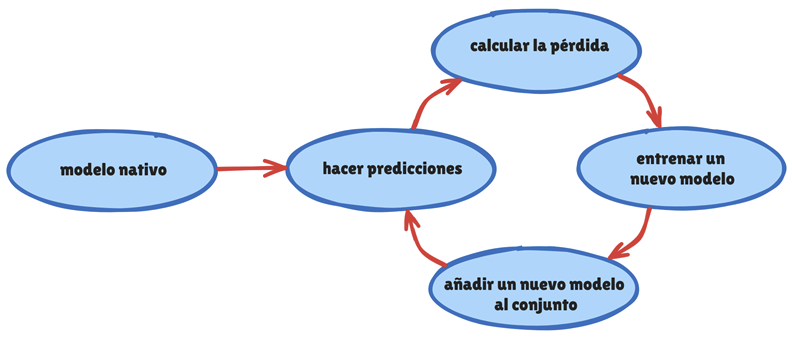

### **Ejemplo**
Comenzamos cargando los datos de entrenamiento y validación en X_train, X_valid, y_train y y_valid.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

print("Path to dataset files:", path)

# Load the data into a pandas DataFrame
melbourne_file_path = path + '/melb_data.csv'
melbourne_data = pd.read_csv(melbourne_file_path)

# Print the first 5 rows of the DataFrame
display(melbourne_data.shape)

# Select subset of predictors
cols_to_use = ['Rooms', 'Distance', 'Landsize', 'BuildingArea', 'YearBuilt']
X = melbourne_data[cols_to_use]

# Select target
y = melbourne_data.Price

# Separate data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y)

En este ejemplo, trabajarás con la biblioteca XGBoost. XGBoost significa 'extreme gradient boosting', que es una implementación de boosting por gradiente con varias funciones adicionales centradas en el rendimiento y la velocidad. (Scikit-learn tiene otra versión de boosting por gradiente, pero XGBoost presenta algunas ventajas técnicas.)
En la siguiente celda de código, importamos la API de scikit-learn para XGBoost [xgboost.XGBRegressor](https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn). Esto nos permite construir y ajustar un modelo de la misma forma que en scikit-learn. Como verás en la salida, la clase XGBRegressor tiene muchos parámetros ajustables — ¡aprenderás sobre ellos pronto!

In [ ]:
from xgboost import XGBRegressor

my_model = XGBRegressor()
my_model.fit(X_train, y_train)

También realizamos predicciones y evaluamos el modelo.

In [ ]:
from sklearn.metrics import mean_absolute_error

predictions = my_model.predict(X_valid)
print("Mean Absolute Error: " + str(mean_absolute_error(predictions, y_valid)))

### **Ajuste de Parámetros**
XGBoost cuenta con algunos parámetros que pueden afectar de manera significativa la precisión y la velocidad de entrenamiento. Los primeros parámetros que debes entender son:

`n_estimators`

`n_estimators` especifica cuántas veces se debe realizar el ciclo de modelado descrito anteriormente. Es igual al número de modelos que incluimos en el ensamblaje.
* Un valor demasiado bajo provoca subajuste, lo que conduce a predicciones inexactas tanto en los datos de entrenamiento como en los datos de prueba.
* Un valor demasiado alto provoca sobreajuste, que produce predicciones precisas en los datos de entrenamiento, pero inexactas en los datos de prueba (que es lo que nos importa).

Los valores típicos oscilan entre 100 y 1000, aunque esto depende mucho del parámetro `learning_rate` que se explica a continuación.

Aquí tienes el código para establecer el número de modelos en el ensamblaje:

In [ ]:
my_model = XGBRegressor(n_estimators=500)
my_model.fit(X_train, y_train)

### **early_stopping_rounds** (paradas_tempranas_por_rondas)
Los `early_stopping_rounds` ofrecen una forma de encontrar automáticamente el valor ideal para `n_estimators`. La parada temprana hace que el modelo deje de iterar cuando la puntuación de validación deja de mejorar, incluso si no hemos alcanzado el límite establecido para `n_estimators`. Es recomendable establecer un valor alto para `n_estimators` y luego usar las `early_stopping_rounds` para determinar el momento óptimo para detener la iteración.

Dado que la probabilidad aleatoria a veces provoca una ronda en la que las puntuaciones de validación no mejoran, es necesario especificar un número de rondas consecutivas de deterioro antes de detenerse. Configurar `early_stopping_rounds=5` es una opción razonable. En este caso, se detiene después de 5 rondas consecutivas de deterioro en las puntuaciones de validación.

Al usar los `early_stopping_rounds=5`, también es necesario reservar algunos datos para calcular las puntuaciones de validación, lo cual se hace configurando el parámetro `eval_set`.
Podemos modificar el ejemplo anterior para incluir la parada temprana:

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Define parameters
n_estimators = 500
early_stopping_rounds = 5

my_model = XGBRegressor(n_estimators=1) # Start with 1 estimator

best_mae = float('inf')
rounds_without_improvement = 0

for i in range(n_estimators):
    # Train for one boosting round
    my_model.n_estimators = i + 1
    my_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

    # Make predictions and calculate MAE on the validation set
    predictions = my_model.predict(X_valid)
    mae = mean_absolute_error(predictions, y_valid)

    # Check for early stopping
    if mae < best_mae:
        best_mae = mae
        rounds_without_improvement = 0
    else:
        rounds_without_improvement += 1
        if rounds_without_improvement >= early_stopping_rounds:
            print(f"Early stopping at round {i+1}. Best MAE: {best_mae}")
            break

print(f"Training finished. Final number of estimators: {my_model.n_estimators}")

Si en algún momento deseas ajustar un modelo con todos tus datos, configura `n_estimators` con el valor que hayas encontrado como óptimo al usar `early stopping`.
### **learning_rate**
En lugar de obtener predicciones simplemente sumando las predicciones de cada modelo componente, podemos multiplicar las predicciones de cada modelo por un número pequeño (conocido como tasa de aprendizaje) antes de sumarlas.
Esto significa que cada árbol que añadimos al conjunto ayuda cada vez menos. Por lo tanto, podemos establecer un valor más alto para `n_estimators` sin sobreajustar. Si utilizamos `early stopping`, el número adecuado de árboles se determinará automáticamente.

En general, una tasa de aprendizaje `learning_rate` pequeña y un gran número de estimadores `n_estimators` producirán modelos de XGBoost más precisos, aunque también llevará más tiempo entrenar el modelo, ya que realiza más iteraciones en el ciclo. Por defecto, `XGBoost` establece `learning_rate=0.1`.

Modificar el ejemplo anterior para cambiar la tasa de aprendizaje produce el siguiente código:

In [ ]:
# Define parameters
n_estimators = 500
early_stopping_rounds = 5

my_model = XGBRegressor(n_estimators=1, learning_rate=0.05) # Start with 1 estimator

best_mae = float('inf')
rounds_without_improvement = 0

for i in range(n_estimators):
    # Train for one boosting round
    my_model.n_estimators = i + 1
    my_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

    # Make predictions and calculate MAE on the validation set
    predictions = my_model.predict(X_valid)
    mae = mean_absolute_error(predictions, y_valid)

    # Check for early stopping
    if mae < best_mae:
        best_mae = mae
        rounds_without_improvement = 0
    else:
        rounds_without_improvement += 1
        if rounds_without_improvement >= early_stopping_rounds:
            print(f"Early stopping at round {i+1}. Best MAE: {best_mae}")
            break

print(f"Training finished. Final number of estimators: {my_model.n_estimators}")

### **n_jobs**
En conjuntos de datos más grandes donde el tiempo de ejecución es un factor, puedes usar el paralelismo para construir tus modelos más rápidamente. Es habitual establecer el parámetro `n_jobs` igual al número de núcleos de tu máquina. En conjuntos de datos más pequeños, esto no será de ayuda.
El modelo resultante no será mejor, por lo que micro-optimizar el tiempo de ajuste suele ser simplemente una distracción. Sin embargo, resulta útil en conjuntos de datos grandes, donde de otro modo tendrías que esperar mucho tiempo durante la ejecución de la función fit.
Aquí tienes el ejemplo modificado:

In [ ]:
# Define parameters
n_estimators = 500
early_stopping_rounds = 5

my_model = XGBRegressor(n_estimators=1, learning_rate=0.05, n_jobs=24) # Start with 1 estimator

best_mae = float('inf')
rounds_without_improvement = 0

for i in range(n_estimators):
    # Train for one boosting round
    my_model.n_estimators = i + 1
    my_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

    # Make predictions and calculate MAE on the validation set
    predictions = my_model.predict(X_valid)
    mae = mean_absolute_error(predictions, y_valid)

    # Check for early stopping
    if mae < best_mae:
        best_mae = mae
        rounds_without_improvement = 0
    else:
        rounds_without_improvement += 1
        if rounds_without_improvement >= early_stopping_rounds:
            print(f"Early stopping at round {i+1}. Best MAE: {best_mae}")
            break

print(f"Training finished. Final number of estimators: {my_model.n_estimators}")

### **Conclusión**
`XGBoost` es una biblioteca de software líder para trabajar con datos tabulares estándar (el tipo de datos que se almacenan en DataFrames de Pandas, en contraposición a tipos de datos más exóticos como imágenes y vídeos). Con un ajuste cuidadoso de los parámetros, puedes entrenar modelos altamente precisos.